# stats_arrays demo

`stats_arrays` provides a consistent interface for working with uncertainty distributions in NumPy. Each distribution is parameterised using a structured NumPy array (the *params array*), which makes it straightforward to work with large collections of uncertain values at once.

This notebook covers:

1. Building params arrays
2. Available distributions and `UncertaintyType`
3. Generating random samples (Monte Carlo and Latin Hypercube)
4. Inspecting distributions: statistics, PDF, CDF, and PPF
5. A worked example: simple Monte Carlo propagation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import stats_arrays as sa
from stats_arrays import (
    UncertaintyType,
    UncertaintyBase,
    NormalUncertainty,
    LognormalUncertainty,
    TriangularUncertainty,
    UniformUncertainty,
    BetaUncertainty,
    MCRandomNumberGenerator,
    LatinHypercubeRNG,
)

%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 4)

## 1  Building params arrays

Every distribution is described by a row in a structured NumPy array with these fields:

| Field | Meaning |
|---|---|
| `loc` | Location (mean / μ for Normal; log-mean for Lognormal; etc.) |
| `scale` | Scale (σ for Normal; log-σ for Lognormal; etc.) |
| `shape` | Shape parameter (e.g. α for Beta, k for Weibull) |
| `minimum` | Optional lower bound |
| `maximum` | Optional upper bound |
| `negative` | If True, the sampled value is negated |
| `uncertainty_type` | Integer ID selecting the distribution |

The two convenience constructors are `from_dicts` (flexible) and `from_tuples` (compact).

In [2]:
# from_dicts: only supply the fields you need; the rest default to NaN / False / 0
params = UncertaintyBase.from_dicts(
    {"loc": 2.0,  "scale": 0.5, "uncertainty_type": UncertaintyType.normal},
    {"loc": 1.0,  "scale": 0.3, "uncertainty_type": UncertaintyType.lognormal},
    {"loc": 0.5,  "minimum": 0.0, "maximum": 1.0,
     "uncertainty_type": UncertaintyType.triangular},
)
params

array([(2. , 0.5, nan, nan, nan, False, 3),
       (1. , 0.3, nan, nan, nan, False, 2),
       (0.5, nan, nan,  0.,  1., False, 5)],
      dtype=[('loc', '<f8'), ('scale', '<f8'), ('shape', '<f8'), ('minimum', '<f8'), ('maximum', '<f8'), ('negative', '?'), ('uncertainty_type', 'u1')])

In [3]:
# from_tuples: order is (loc, scale, shape, minimum, maximum, negative, uncertainty_type)
params_t = UncertaintyBase.from_tuples(
    (2.0, 0.5, np.nan, np.nan, np.nan, False, UncertaintyType.normal),
    (1.0, 0.3, np.nan, np.nan, np.nan, False, UncertaintyType.lognormal),
)
params_t

array([(2., 0.5, nan, nan, nan, False, 3),
       (1., 0.3, nan, nan, nan, False, 2)],
      dtype=[('loc', '<f8'), ('scale', '<f8'), ('shape', '<f8'), ('minimum', '<f8'), ('maximum', '<f8'), ('negative', '?'), ('uncertainty_type', 'u1')])

## 2  Available distributions

`UncertaintyType` is an `IntEnum` mapping names to the integer IDs stored in params arrays.  It is fully backwards-compatible with plain integers.

In [4]:
for ut in UncertaintyType:
    print(f"  {ut.value:>3}  {ut.name}")

    0  undefined
    1  no_uncertainty
    2  lognormal
    3  normal
    4  uniform
    5  triangular
    6  bernoulli
    7  discrete_uniform
    8  weibull
    9  gamma
   10  beta
   11  generalized_extreme_value
   12  students_t
   13  beta_pert


In [5]:
# UncertaintyType members compare equal to plain ints
assert UncertaintyType.normal == 3
assert UncertaintyType.lognormal == 2

# Look up the distribution class for a given ID
from stats_arrays import uncertainty_choices
print(uncertainty_choices[UncertaintyType.normal])

<class 'stats_arrays.distributions.normal.NormalUncertainty'>


## 3  Generating random samples

### 3.1  Monte Carlo (`MCRandomNumberGenerator`)

`MCRandomNumberGenerator` iterates over a params array, yielding one sample vector per call to `next()`.  Mixed distribution types are handled automatically.

In [6]:
params_mc = UncertaintyBase.from_dicts(
    {"loc": 10.0, "scale": 1.0,  "uncertainty_type": UncertaintyType.normal},
    {"loc": 0.5,  "scale": 0.2,  "uncertainty_type": UncertaintyType.lognormal},
    {"loc": 3.0,  "minimum": 1.0, "maximum": 5.0,
     "uncertainty_type": UncertaintyType.triangular},
)

rng = MCRandomNumberGenerator(params_mc, seed=42)

# Draw three independent samples
for i in range(3):
    sample = next(rng)
    print(f"Sample {i+1}: {sample.ravel()}")

Sample 1: [9.8617357  1.82092175 3.53574303]
Sample 2: [10.31890218  1.31998976  2.11711958]
Sample 3: [10.76743473  2.26107997  1.40580285]


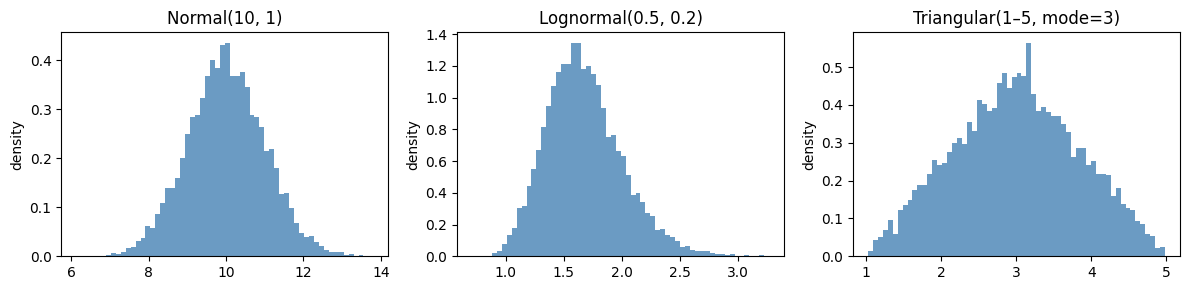

In [7]:
# Collect many samples to inspect the empirical distributions
N = 10_000
rng = MCRandomNumberGenerator(params_mc, seed=0)
samples = np.vstack([next(rng) for _ in range(N)]).T   # shape (3, N)

labels = ["Normal(10, 1)", "Lognormal(0.5, 0.2)", "Triangular(1–5, mode=3)"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, row, label in zip(axes, samples, labels):
    ax.hist(row, bins=60, density=True, color='steelblue', alpha=0.8)
    ax.set_title(label)
    ax.set_ylabel("density")
plt.tight_layout()

### 3.2  Latin Hypercube sampling (`LatinHypercubeRNG`)

Latin Hypercube sampling stratifies the probability space to give better coverage of each distribution with fewer samples than plain Monte Carlo.

LHC hypercube shape: (3, 200)


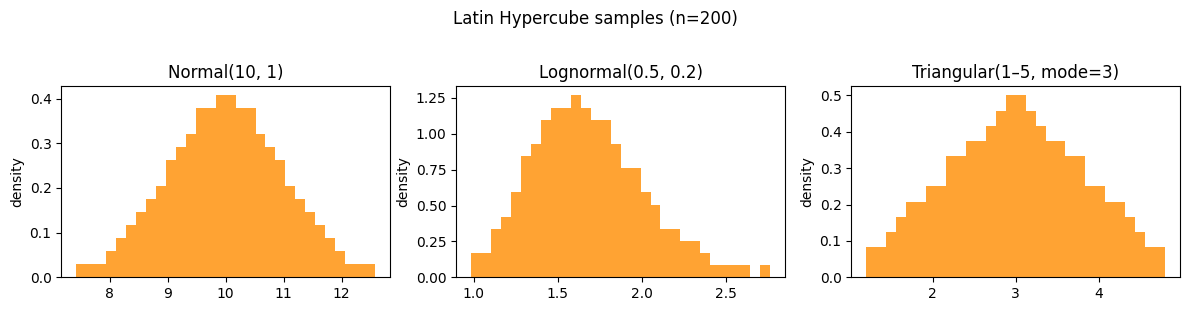

In [8]:
lhc = LatinHypercubeRNG(params_mc, samples=200, seed=42)
print("LHC hypercube shape:", lhc.hypercube.shape)   # (n_distributions, n_samples)

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, row, label in zip(axes, lhc.hypercube, labels):
    ax.hist(row, bins=30, density=True, color='darkorange', alpha=0.8)
    ax.set_title(label)
    ax.set_ylabel("density")
plt.suptitle("Latin Hypercube samples (n=200)", y=1.02)
plt.tight_layout()

## 4  Inspecting distributions

Each distribution class exposes `statistics()`, `pdf()`, `cdf()`, and `ppf()` as class methods.

### 4.1  Summary statistics

In [9]:
p_norm = UncertaintyBase.from_dicts(
    {"loc": 5.0, "scale": 1.5, "uncertainty_type": UncertaintyType.normal}
)
NormalUncertainty.statistics(p_norm)

{'mean': 5.0, 'mode': 5.0, 'median': 5.0, 'lower': 2.0, 'upper': 8.0}

In [10]:
p_tri = UncertaintyBase.from_dicts(
    {"loc": 3.0, "minimum": 1.0, "maximum": 8.0,
     "uncertainty_type": UncertaintyType.triangular}
)
TriangularUncertainty.statistics(p_tri)

{'mean': 4.0,
 'median': 3.8166998673296226,
 'mode': 3.0,
 'lower': 1.4183300132670378,
 'upper': 7.338562172233853}

### 4.2  PDF plots for several distributions

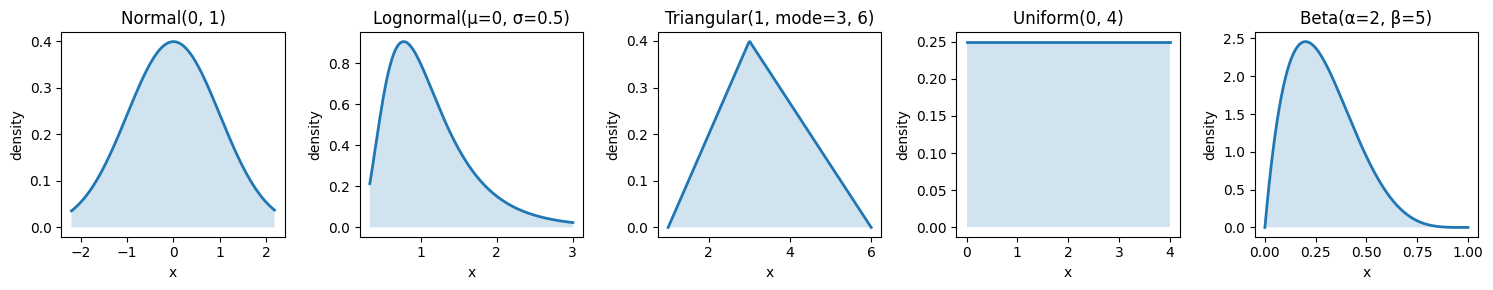

In [11]:
distributions = [
    (NormalUncertainty,
     UncertaintyBase.from_dicts({"loc": 0.0, "scale": 1.0,
                                  "uncertainty_type": UncertaintyType.normal}),
     "Normal(0, 1)"),
    (LognormalUncertainty,
     UncertaintyBase.from_dicts({"loc": 0.0, "scale": 0.5,
                                  "uncertainty_type": UncertaintyType.lognormal}),
     "Lognormal(μ=0, σ=0.5)"),
    (TriangularUncertainty,
     UncertaintyBase.from_dicts({"loc": 3.0, "minimum": 1.0, "maximum": 6.0,
                                  "uncertainty_type": UncertaintyType.triangular}),
     "Triangular(1, mode=3, 6)"),
    (UniformUncertainty,
     UncertaintyBase.from_dicts({"loc": 2.0, "minimum": 0.0, "maximum": 4.0,
                                  "uncertainty_type": UncertaintyType.uniform}),
     "Uniform(0, 4)"),
    (BetaUncertainty,
     UncertaintyBase.from_dicts({"loc": 2.0, "shape": 5.0,
                                  "uncertainty_type": UncertaintyType.beta}),
     "Beta(α=2, β=5)"),
]

fig, axes = plt.subplots(1, len(distributions), figsize=(15, 3))
for ax, (cls, params, title) in zip(axes, distributions):
    xs, ys = cls.pdf(params)
    ax.plot(xs, ys, lw=2)
    ax.fill_between(xs, ys, alpha=0.2)
    ax.set_title(title)
    ax.set_ylabel("density")
    ax.set_xlabel("x")
plt.tight_layout()

### 4.3  CDF and PPF

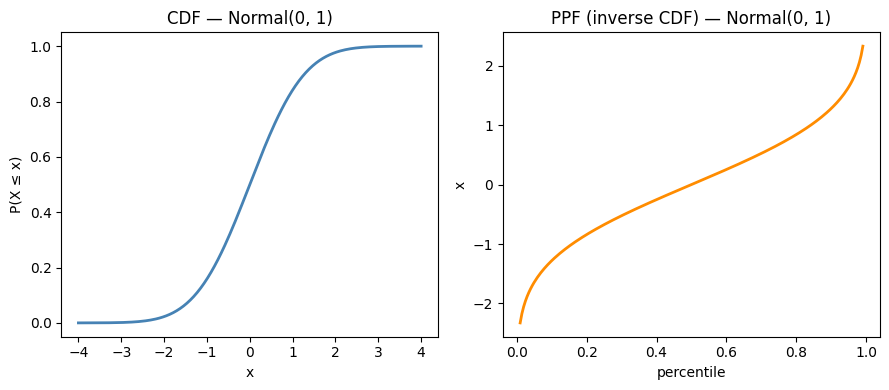

In [12]:
p = UncertaintyBase.from_dicts(
    {"loc": 0.0, "scale": 1.0, "uncertainty_type": UncertaintyType.normal}
)

xs = np.linspace(-4, 4, 200)
cdf_vals = NormalUncertainty.cdf(p, xs.reshape(1, -1)).ravel()

percentiles = np.linspace(0.01, 0.99, 200).reshape(1, -1)
ppf_vals = NormalUncertainty.ppf(p, percentiles).ravel()

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(xs, cdf_vals, lw=2, color='steelblue')
ax1.set_title("CDF — Normal(0, 1)")
ax1.set_xlabel("x"); ax1.set_ylabel("P(X ≤ x)")

ax2.plot(percentiles.ravel(), ppf_vals, lw=2, color='darkorange')
ax2.set_title("PPF (inverse CDF) — Normal(0, 1)")
ax2.set_xlabel("percentile"); ax2.set_ylabel("x")
plt.tight_layout()

### 4.4  Bounded sampling

`bounded_random_variables` rejects samples outside [minimum, maximum] and redraws until all samples are in-bounds.

All in [-1, 1]: True


Text(0.5, 1.0, 'Bounded Normal(0, 1) — truncated to [-1, 1]')

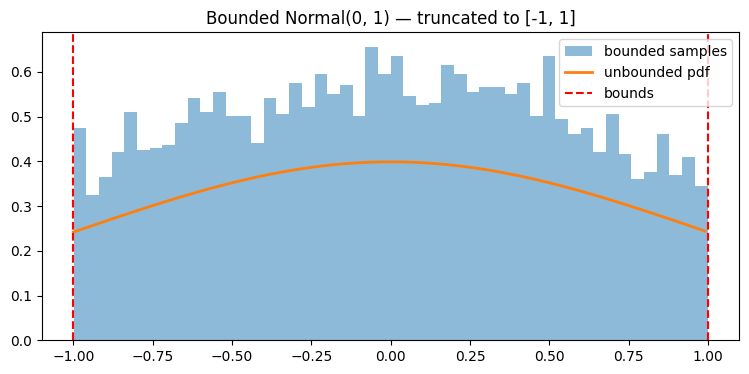

In [13]:
p_bounded = UncertaintyBase.from_dicts(
    {"loc": 0.0, "scale": 1.0, "minimum": -1.0, "maximum": 1.0,
     "uncertainty_type": UncertaintyType.normal}
)

rng_state = np.random.RandomState(42)
samples = NormalUncertainty.bounded_random_variables(p_bounded, size=5000,
                                                      seeded_random=rng_state)
print(f"All in [-1, 1]: {(np.abs(samples) <= 1).all()}")

xs, ys = NormalUncertainty.pdf(p_bounded)
fig, ax = plt.subplots()
ax.hist(samples.ravel(), bins=50, density=True, alpha=0.5, label="bounded samples")
ax.plot(xs, ys, lw=2, label="unbounded pdf")
ax.axvline(-1, color='red', linestyle='--', label="bounds")
ax.axvline( 1, color='red', linestyle='--')
ax.legend(); ax.set_title("Bounded Normal(0, 1) — truncated to [-1, 1]")

## 5  Worked example: Monte Carlo uncertainty propagation

A simple life-cycle-style calculation:

$$\text{impact} = A \times B \times C$$

where each factor has its own uncertainty.  We propagate uncertainty through the product using Monte Carlo.

In [14]:
# Three uncertain factors
params_lca = UncertaintyBase.from_dicts(
    # A: activity level — normally distributed
    {"loc": 100.0, "scale": 10.0, "uncertainty_type": UncertaintyType.normal},
    # B: emission factor — lognormal (always positive)
    {"loc": np.log(0.05), "scale": 0.3, "uncertainty_type": UncertaintyType.lognormal},
    # C: characterisation factor — triangular expert estimate
    {"loc": 2.5, "minimum": 1.0, "maximum": 4.0,
     "uncertainty_type": UncertaintyType.triangular},
)

N = 50_000
rng = MCRandomNumberGenerator(params_lca, seed=123)
draws = np.vstack([next(rng) for _ in range(N)]).T   # shape (3, N)

A, B, C = draws
impact = A * B * C

print(f"Mean impact:   {impact.mean():.3f}")
print(f"Std deviation: {impact.std():.3f}")
print(f"2.5th pct:     {np.percentile(impact, 2.5):.3f}")
print(f"97.5th pct:    {np.percentile(impact, 97.5):.3f}")

Mean impact:   13.080
Std deviation: 5.428
2.5th pct:     5.205
97.5th pct:    26.137


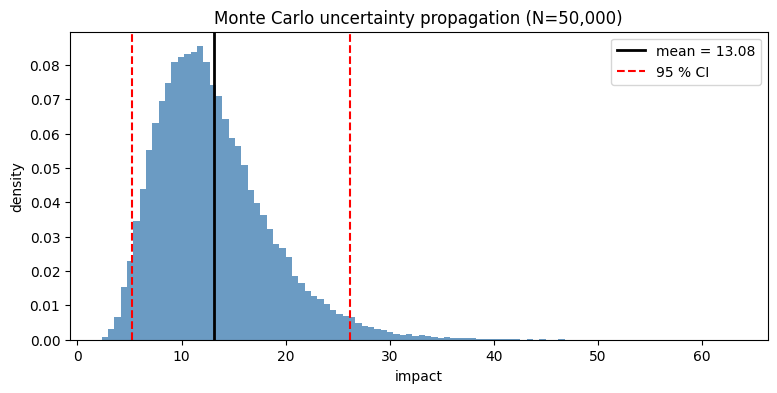

In [15]:
fig, ax = plt.subplots()
ax.hist(impact, bins=100, density=True, color='steelblue', alpha=0.8)
ax.axvline(impact.mean(), color='black', lw=2, label=f"mean = {impact.mean():.2f}")
ax.axvline(np.percentile(impact, 2.5),  color='red', lw=1.5, linestyle='--',
           label="95 % CI")
ax.axvline(np.percentile(impact, 97.5), color='red', lw=1.5, linestyle='--')
ax.set_xlabel("impact")
ax.set_ylabel("density")
ax.set_title("Monte Carlo uncertainty propagation (N=50,000)")
ax.legend()